# Getting Started — CPI Gasoline Backtest

The bootcamp's **hello-world** forecasting experiment.  Run this notebook
top to bottom for an end-to-end tour of the evaluation framework on a
single, deliberately-hard target.

**Task.** Forecast Canada CPI Gasoline (index, 2002=100) exactly 12
months ahead.  Evaluated at January and July origins from 2000 to 2026.

**Why gasoline.** Because it *breaks* our models.  The series has four
textbook regime shifts in the evaluation window — the 2008 crude-oil
collapse, the 2014–16 OPEC-led decline, the 2020 COVID demand shock,
and the 2021–22 Russia/Ukraine surge.  A 12-month-ahead forecast sees
through each one blind.  That makes gasoline a good motivator for
everything downstream: exogenous covariates, LLM context, agentic news
retrieval.

**Predictors.**

- `LastValuePredictor` — naive last-value baseline from `methods.naive`.
  The performance floor every predictor must beat.
- `DartsAutoARIMAPredictor` — Darts `AutoARIMA` wrapped to emit
  probabilistic forecasts via Monte Carlo sampling.  Imported from
  `methods.darts_arima`.

**Score.** CRPS (lower is better) is the primary metric — it rewards both
calibration and sharpness.

**Prerequisites.**

```bash
uv run python scripts/fetch_cpi.py
```

In [1]:
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd
import yaml


ROOT = Path.cwd().resolve().parents[2]

## 1. Register CPI Gasoline

In [2]:
from aieng.forecasting.data import DataService, SeriesMetadata
from aieng.forecasting.data.adapters import StatCanAdapter


CPI_TABLE_ID = "18-10-0004-11"
CACHE_DIR = ROOT / "data" / "statcan"

svc = DataService()

gasoline_adapter = StatCanAdapter(
    table_id=CPI_TABLE_ID,
    member_filter={"GEO": "Canada", "Products and product groups": "Gasoline"},
    cache_dir=CACHE_DIR,
)
svc.register(
    "cpi_gasoline_canada",
    gasoline_adapter,
    SeriesMetadata(
        series_id="cpi_gasoline_canada",
        description="CPI Gasoline, Canada (2002=100)",
        source="StatCan table 18-10-0004-11",
        units="Index 2002=100",
        frequency="MS",
        table_id=CPI_TABLE_ID,
    ),
)

# Shelter is pre-registered too so the "try this next" cell at the end
# can re-run the backtest against a totally different inflation dynamic
# without any setup rerun.
shelter_adapter = StatCanAdapter(
    table_id=CPI_TABLE_ID,
    member_filter={"GEO": "Canada", "Products and product groups": "Shelter"},
    cache_dir=CACHE_DIR,
)
svc.register(
    "cpi_shelter_canada",
    shelter_adapter,
    SeriesMetadata(
        series_id="cpi_shelter_canada",
        description="CPI Shelter, Canada (2002=100)",
        source="StatCan table 18-10-0004-11",
        units="Index 2002=100",
        frequency="MS",
        table_id=CPI_TABLE_ID,
    ),
)

svc.summary()

,series_id,description,source,units,frequency,n_obs,start,end
0,cpi_gasoline_canada,"CPI Gasoline, Canada (2002=100)",StatCan table 18-10-0004-11,Index 2002=100,MS,926,1949-01-01,2026-02-01
1,cpi_shelter_canada,"CPI Shelter, Canada (2002=100)",StatCan table 18-10-0004-11,Index 2002=100,MS,570,1978-09-01,2026-02-01


## 2. Load the reference spec

In [3]:
from aieng.forecasting.evaluation import BacktestSpec


spec_path = ROOT / "reference_specs" / "cpi_gasoline_12m.yaml"
with spec_path.open() as f:
    spec = BacktestSpec.model_validate(yaml.safe_load(f))

origins = spec.origins()
print(f"Task:    {spec.task.task_id}")
print(f"Target:  {spec.task.target_series_id}")
print(f"Horizon: {spec.task.horizon} months")
print(f"Origins: {len(origins)} ({origins[0].date()} → {origins[-1].date()})")
print(f"Warmup:  {spec.warmup} observations")

Task:    cpi_gasoline_canada_12m
Target:  cpi_gasoline_canada
Horizon: 12 months
Origins: 53 (2000-01-01 → 2026-01-01)
Warmup:  24 observations


## 3. Define the predictors

- **`LastValuePredictor`** — `methods.naive`.  No fitting required;
  predicts the last observed value at every quantile.  The floor.
- **`DartsAutoARIMAPredictor`** — `methods.darts_arima`.  Wraps
  Darts `AutoARIMA` with Monte Carlo sampling for quantile
  estimates.  Univariate only.

Read `implementations/methods/naive.py` for an annotated reference on
how to satisfy the `Predictor` ABC when you write your own.

In [4]:
from methods.darts_arima import DartsAutoARIMAPredictor
from methods.naive import LastValuePredictor


naive_predictor = LastValuePredictor()
arima_predictor = DartsAutoARIMAPredictor(num_samples=500)
print(f"Predictors: {naive_predictor.predictor_id}, {arima_predictor.predictor_id}")

Predictors: last_value_naive, darts_autoarima


## 4. Run both backtests

The naive backtest is instant.  AutoARIMA fits once per origin — expect
a couple of minutes on a laptop.

In [5]:
from aieng.forecasting.evaluation import backtest


naive_results = backtest(predictor=naive_predictor, spec=spec, data_service=svc)
arima_results = backtest(predictor=arima_predictor, spec=spec, data_service=svc)

print(f"{'Predictor':<30} {'Origins':>8} {'Skipped':>8} {'Mean CRPS':>10}")
print("-" * 60)
for r in [naive_results, arima_results]:
    print(f"{r.predictor_id:<30} {len(r.predictions):>8} {r.skipped_origins:>8} {r.mean_crps:>10.4f}")

Support for PyTorch based likelihood models not available. To enable them, install "darts[torch]" or "darts[all]" (with pip); or "u8darts-torch" or "u8darts-all" (with conda).


Support for Torch based models not available. To enable them, install "darts[torch]" or "darts[all]" (with pip); or "u8darts-torch" or "u8darts-all" (with conda).


/Users/ethanjackson/agentic-forecasting/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Predictor                       Origins  Skipped  Mean CRPS
------------------------------------------------------------
last_value_naive                     51        2    21.4863
darts_autoarima                      51        2    16.8144


## 5. Per-origin CRPS comparison

Mean CRPS is a single number; the per-origin breakdown tells the
actual story.

In [6]:
def result_to_df(result, label):
    return pd.DataFrame(
        {
            "origin": [p.as_of.date() for p in result.predictions],
            "forecast_date": [p.forecast_date.date() for p in result.predictions],
            f"point_{label}": [p.payload.point_forecast for p in result.predictions],
            f"crps_{label}": result.scores,
        }
    ).set_index("forecast_date")


naive_df = result_to_df(naive_results, "naive")
arima_df = result_to_df(arima_results, "arima")

comparison = naive_df.join(arima_df[["point_arima", "crps_arima"]], how="inner")
comparison["crps_reduction"] = comparison["crps_naive"] - comparison["crps_arima"]

print(f"Mean CRPS  naive:  {comparison['crps_naive'].mean():.4f}")
print(f"Mean CRPS  arima:  {comparison['crps_arima'].mean():.4f}")
print(
    f"Mean reduction:    {comparison['crps_reduction'].mean():.4f}"
    f"  ({comparison['crps_reduction'].mean() / comparison['crps_naive'].mean() * 100:.1f}%)"
)
comparison.reset_index().head(10)

Mean CRPS  naive:  21.4863
Mean CRPS  arima:  16.8144
Mean reduction:    4.6718  (21.7%)


,forecast_date,origin,point_naive,crps_naive,point_arima,crps_arima,crps_reduction
0,2001-01-01,2000-01-01,93.9,9.2,95.466134,4.709652,4.490348
1,2001-07-01,2000-07-01,107.1,9.5,109.718979,9.195716,0.304284
2,2002-01-01,2001-01-01,104.8,18.1,105.666544,15.963557,2.136443
3,2002-07-01,2001-07-01,108.0,5.5,108.681949,3.743364,1.756636
4,2003-01-01,2002-01-01,84.5,23.9,85.664221,19.478216,4.421784
5,2003-07-01,2002-07-01,99.7,2.7,103.077064,1.479711,1.220289
6,2004-01-01,2003-01-01,102.2,3.6,104.054812,1.676355,1.923645
7,2004-07-01,2003-07-01,100.5,20.2,104.080348,13.527383,6.672617
8,2005-01-01,2004-01-01,100.0,14.9,102.948926,8.891213,6.008787
9,2005-07-01,2004-07-01,125.1,10.4,122.222696,9.642161,0.757839


## 6. Predictions vs. actuals — the visual story

One chart, last ~16 years of data, with AutoARIMA's 80% CI shaded so the
model's uncertainty (and its collapses) are visible next to the observed
series.  A companion panel underneath shows per-origin CRPS over time —
the spikes line up with the regime shifts.

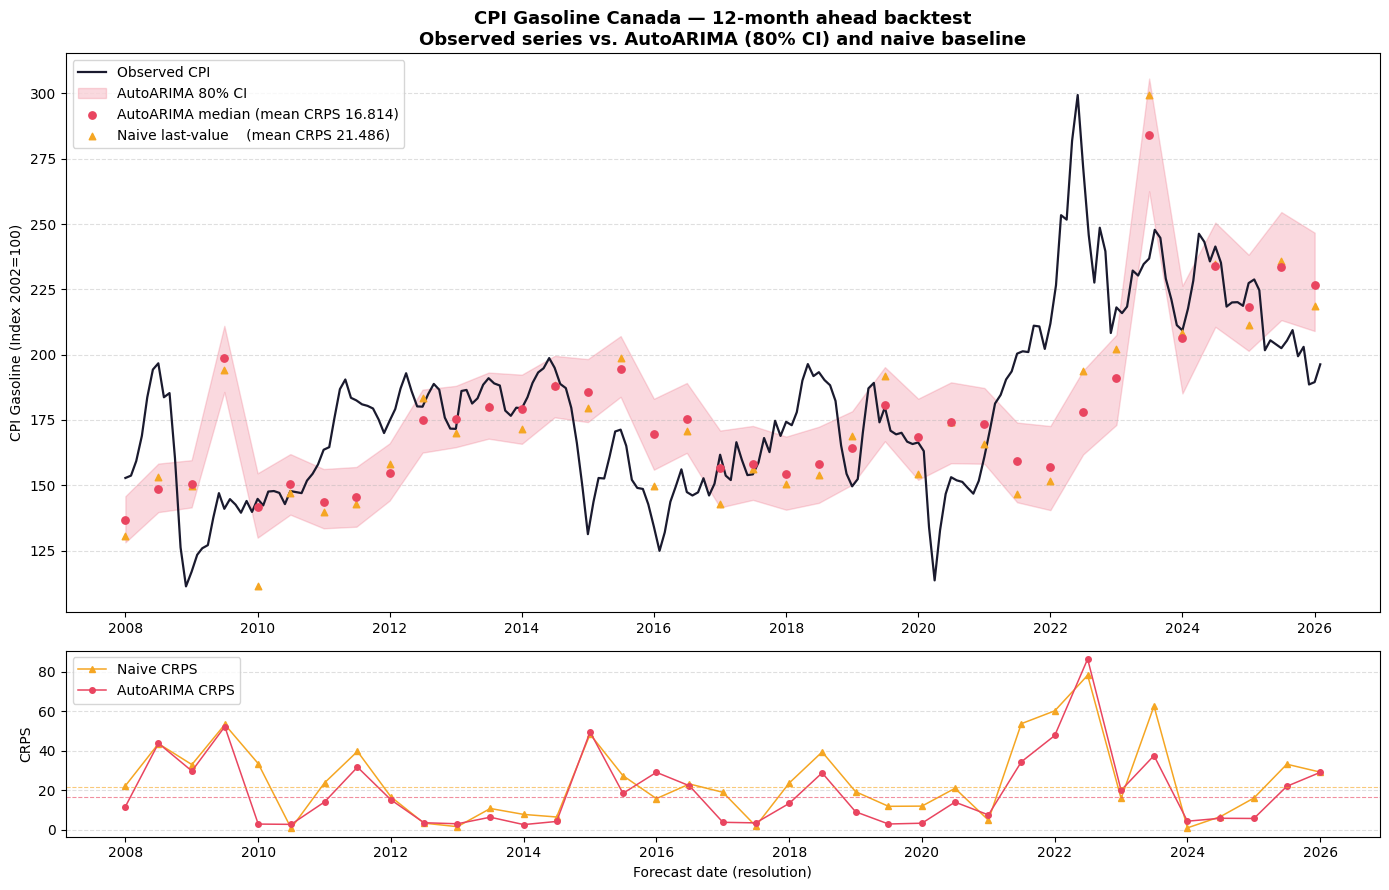

In [7]:
COLOR_OBS = "#1a1a2e"
COLOR_ARIMA = "#e94560"
COLOR_NAIVE = "#f5a623"

full_series = svc.get_series(
    "cpi_gasoline_canada",
    as_of=datetime.now(tz=timezone.utc).replace(tzinfo=None),
)
PLOT_START = pd.Timestamp("2008-01-01")
plot_series = full_series[full_series["timestamp"] >= PLOT_START]

arima_dates = [p.forecast_date for p in arima_results.predictions]
arima_points = [p.payload.point_forecast for p in arima_results.predictions]
arima_q10 = [p.payload.quantiles.get(0.10, p.payload.point_forecast) for p in arima_results.predictions]
arima_q90 = [p.payload.quantiles.get(0.90, p.payload.point_forecast) for p in arima_results.predictions]

naive_dates = [p.forecast_date for p in naive_results.predictions]
naive_points = [p.payload.point_forecast for p in naive_results.predictions]

# Trim plotted predictions to the visible window.
arima_mask = [d >= PLOT_START.to_pydatetime() for d in arima_dates]
arima_dates_p = [d for d, keep in zip(arima_dates, arima_mask) if keep]
arima_points_p = [v for v, keep in zip(arima_points, arima_mask) if keep]
arima_q10_p = [v for v, keep in zip(arima_q10, arima_mask) if keep]
arima_q90_p = [v for v, keep in zip(arima_q90, arima_mask) if keep]
arima_scores_p = [s for s, keep in zip(arima_results.scores, arima_mask) if keep]

naive_mask = [d >= PLOT_START.to_pydatetime() for d in naive_dates]
naive_dates_p = [d for d, keep in zip(naive_dates, naive_mask) if keep]
naive_points_p = [v for v, keep in zip(naive_points, naive_mask) if keep]
naive_scores_p = [s for s, keep in zip(naive_results.scores, naive_mask) if keep]

fig, axes = plt.subplots(2, 1, figsize=(14, 9), gridspec_kw={"height_ratios": [3, 1]})

ax = axes[0]
ax.plot(plot_series["timestamp"], plot_series["value"], color=COLOR_OBS, linewidth=1.6, label="Observed CPI")
ax.fill_between(arima_dates_p, arima_q10_p, arima_q90_p, alpha=0.20, color=COLOR_ARIMA, label="AutoARIMA 80% CI")
ax.scatter(
    arima_dates_p,
    arima_points_p,
    color=COLOR_ARIMA,
    s=28,
    zorder=5,
    label=f"AutoARIMA median (mean CRPS {arima_results.mean_crps:.3f})",
)
ax.scatter(
    naive_dates_p,
    naive_points_p,
    color=COLOR_NAIVE,
    s=22,
    marker="^",
    zorder=4,
    label=f"Naive last-value    (mean CRPS {naive_results.mean_crps:.3f})",
)
ax.set_title(
    "CPI Gasoline Canada — 12-month ahead backtest\nObserved series vs. AutoARIMA (80% CI) and naive baseline",
    fontsize=13,
    fontweight="bold",
)
ax.set_ylabel("CPI Gasoline (Index 2002=100)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.legend(loc="upper left")
ax.grid(axis="y", linestyle="--", alpha=0.4)

ax2 = axes[1]
ax2.plot(naive_dates_p, naive_scores_p, color=COLOR_NAIVE, linewidth=1.1, marker="^", markersize=4, label="Naive CRPS")
ax2.plot(
    arima_dates_p, arima_scores_p, color=COLOR_ARIMA, linewidth=1.1, marker="o", markersize=4, label="AutoARIMA CRPS"
)
ax2.axhline(naive_results.mean_crps, color=COLOR_NAIVE, linestyle="--", linewidth=0.8, alpha=0.6)
ax2.axhline(arima_results.mean_crps, color=COLOR_ARIMA, linestyle="--", linewidth=0.8, alpha=0.6)
ax2.set_ylabel("CRPS")
ax2.set_xlabel("Forecast date (resolution)")
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax2.xaxis.set_major_locator(mdates.YearLocator(2))
ax2.legend(loc="upper left")
ax2.grid(axis="y", linestyle="--", alpha=0.4)

fig.tight_layout()
plt.show()

## 7. Where does it fail?

Sort the per-origin table by AutoARIMA CRPS to see the worst cases.
These are not random outliers — they line up one-for-one with the
macro regime shifts a 12-month-ahead model has no way to see coming.

| Forecast year | Real-world context |
|---|---|
| 2009 | Crude oil collapsed ~70% from its July 2008 peak — 2008 origins project into the trough. |
| 2015–16 | OPEC-led oil price decline; Saudi market-share strategy. |
| 2020–21 | COVID-19 demand shock, then the reopening surge. |
| 2022–23 | Russian invasion of Ukraine drove a global oil shock. |

This table is exactly the motivation for richer methods: exogenous
covariates (FRED crude oil, CAD/USD), LLM context (news, policy), or
agents that can retrieve that context themselves.

In [8]:
worst = comparison.sort_values("crps_arima", ascending=False).head(8)
worst_display = worst.reset_index().assign(
    origin=lambda df: df["origin"].astype(str),
    forecast_date=lambda df: df["forecast_date"].astype(str),
)[["origin", "forecast_date", "point_naive", "point_arima", "crps_naive", "crps_arima"]]
worst_display

,origin,forecast_date,point_naive,point_arima,crps_naive,crps_arima
0,2021-07-01,2022-07-01,193.6,178.171603,78.2,86.443648
1,2008-07-01,2009-07-01,194.3,198.899604,53.3,52.236747
2,2014-01-01,2015-01-01,179.7,185.894672,48.4,49.523831
3,2021-01-01,2022-01-01,151.7,156.956848,60.2,47.726786
4,2007-07-01,2008-07-01,153.1,148.516753,43.6,43.787081
5,2022-07-01,2023-07-01,299.4,284.034179,62.6,37.541938
6,2020-07-01,2021-07-01,146.7,159.227579,53.7,34.398469
7,2010-07-01,2011-07-01,142.8,145.538248,39.7,31.729487


## 8. Spend an eval run (optional)

`evaluate()` is the counterpart to `backtest()`.  It runs against a short
held-out window (`reference_specs/cpi_gasoline_eval_2yr.yaml`) and
decrements a per-participant budget tracked in `data/eval_runs.yaml`
(gitignored).  `max_runs: 5` means each participant may spend at most
five runs against this spec — that deliberate scarcity is what makes
the eval number a real generalisation estimate rather than another
metric to over-fit.

The cell below is **commented out** to protect the budget.  Uncomment
and run it once you have a predictor you're confident about.

```python
from aieng.forecasting.evaluation import EvalSpec, EvalTracker, evaluate

eval_spec_path = ROOT / "reference_specs" / "cpi_gasoline_eval_2yr.yaml"
with eval_spec_path.open() as f:
    eval_spec = EvalSpec.model_validate(yaml.safe_load(f))

tracker = EvalTracker(ROOT / "data" / "eval_runs.yaml")
eval_result = evaluate(
    predictor=arima_predictor,
    spec=eval_spec,
    data_service=svc,
    tracker=tracker,
)
print(
    f"Eval mean CRPS: {eval_result.mean_crps:.4f}  "
    f"(run {eval_result.run_number}/{eval_spec.max_runs})"
)
```

## 9. Try this next: re-run against Shelter

Shelter tells the opposite story to gasoline: sticky trend, low
month-to-month volatility, one large regime shift (2021–24) driven by
housing and monetary policy.  AutoARIMA should do relatively well on
the stationary portion and miss the shift — a different failure mode
from gasoline's.

The cell below constructs a spec variant in Python against the
already-registered `cpi_shelter_canada` series.  For a more persistent
configuration, copy `reference_specs/cpi_gasoline_12m.yaml` to
`reference_specs/cpi_shelter_12m.yaml` and swap the series ID.

After that, the natural graduation step is
`implementations/experiments/food_price_forecasting/` — nine correlated
series, a 12-step trajectory, and the avg/avg YoY metric that
Canada's Food Price Report actually publishes.

In [9]:
from aieng.forecasting.evaluation import ForecastingTask


shelter_spec = BacktestSpec(
    task=ForecastingTask(
        task_id="cpi_shelter_canada_12m",
        target_series_id="cpi_shelter_canada",
        horizons=[12],
        frequency="MS",
        description="CPI Shelter Canada, 12-month ahead forecast.",
    ),
    start=spec.start,
    end=spec.end,
    stride=spec.stride,
    warmup=spec.warmup,
    description="Shelter variant of the getting-started spec — the gasoline foil.",
)

naive_shelter = backtest(predictor=naive_predictor, spec=shelter_spec, data_service=svc)
arima_shelter = backtest(predictor=arima_predictor, spec=shelter_spec, data_service=svc)

print(f"{'Target':<20} {'Predictor':<20} {'Mean CRPS':>10}")
print("-" * 55)
print(f"{'Gasoline':<20} {'Naive':<20} {naive_results.mean_crps:>10.3f}")
print(f"{'Gasoline':<20} {'AutoARIMA':<20} {arima_results.mean_crps:>10.3f}")
print(f"{'Shelter':<20} {'Naive':<20} {naive_shelter.mean_crps:>10.3f}")
print(f"{'Shelter':<20} {'AutoARIMA':<20} {arima_shelter.mean_crps:>10.3f}")

Target               Predictor             Mean CRPS
-------------------------------------------------------
Gasoline             Naive                    21.486
Gasoline             AutoARIMA                16.814
Shelter              Naive                     4.192
Shelter              AutoARIMA                 1.695


## 10. Serialize the result to YAML

`BacktestResult` is a Pydantic model — serialisable to YAML alongside
the predictor implementation, passable to a downstream agent as
structured context, or usable as a submission artefact in a future
leaderboard mechanism.

In [10]:
result_dict = arima_results.model_dump(mode="json")
result_yaml = yaml.dump(result_dict, default_flow_style=False, allow_unicode=True)

print("\n".join(result_yaml.splitlines()[:35]))
print("...")

mean_crps: 16.814426542648793
predictions:
- as_of: '2000-01-01T00:00:00'
  forecast_date: '2001-01-01T00:00:00'
  issued_at: '2026-04-17T19:06:12.276551'
  metadata: {}
  payload:
    point_forecast: 95.46613379833241
    quantiles:
      '0.05': 87.0983054048001
      '0.1': 88.67592076921505
      '0.2': 90.67521803302061
      '0.3': 93.00540546787539
      '0.4': 94.30193496309218
      '0.5': 95.46613379833241
      '0.6': 97.10181542008026
      '0.7': 98.23575564423871
      '0.8': 100.18975213526242
      '0.9': 102.40261996315587
      '0.95': 104.08828772641627
  predictor_id: darts_autoarima
  task_id: cpi_gasoline_canada_12m
- as_of: '2000-07-01T00:00:00'
  forecast_date: '2001-07-01T00:00:00'
  issued_at: '2026-04-17T19:06:12.362625'
  metadata: {}
  payload:
    point_forecast: 109.71897886029507
    quantiles:
      '0.05': 100.49765873751848
      '0.1': 103.14568816859038
      '0.2': 105.4781802080485
      '0.3': 107.19888154548435
      '0.4': 108.4537569712764
   